In [ ]:
import zipfile
import os

zip_path = "/content/drive-download-20260908T163931Z-1-001.zip"
extract_path = "/content/banana_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/banana_dataset


In [ ]:
import os

dataset_path = "/content/banana_dataset"

for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{folder}: {len(images)} images")

print("\nTotal images:", sum(
    len([
        f for f in os.listdir(os.path.join(dataset_path, folder))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
))

Banana Black Sigatoka Disease: 67 images
Banana Bract Mosaic Virus Disease: 50 images
Banana Healthy Leaf: 86 images
Banana Insect Pest Disease: 86 images
Banana Moko Disease: 55 images
Banana Panama Disease: 41 images
Banana Yellow Sigatoka Disease: 23 images

Total images: 408


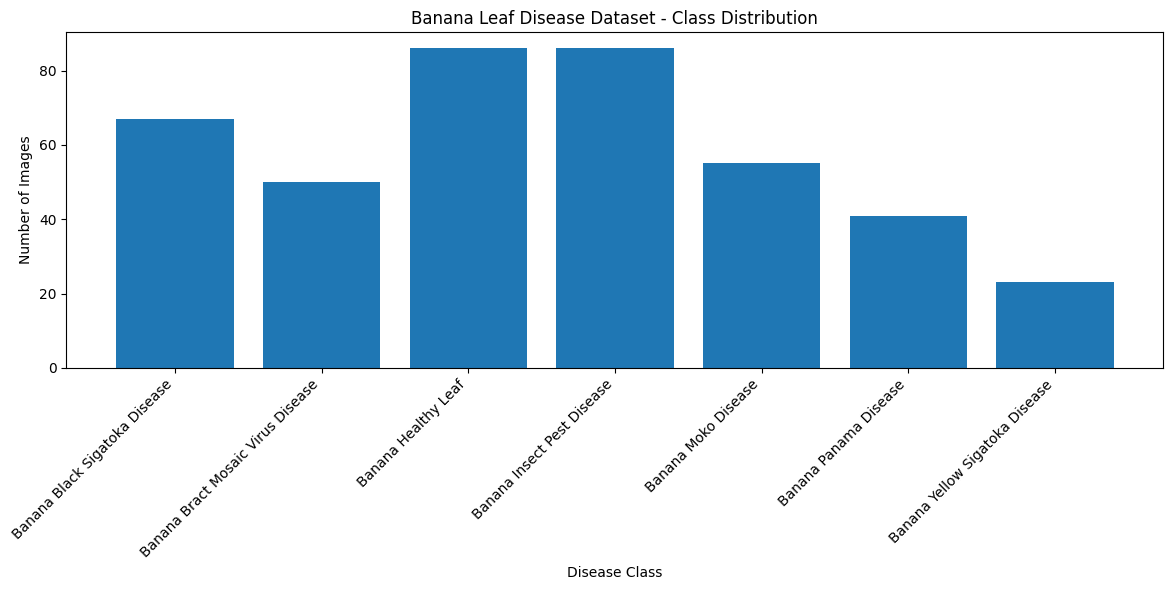

In [ ]:
import os
import matplotlib.pyplot as plt

dataset_path = "/content/banana_dataset"

class_names = []
class_counts = []

for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        class_names.append(folder)
        class_counts.append(count)

plt.figure(figsize=(12, 6))
plt.bar(class_names, class_counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Banana Leaf Disease Dataset - Class Distribution")
plt.tight_layout()
plt.show()

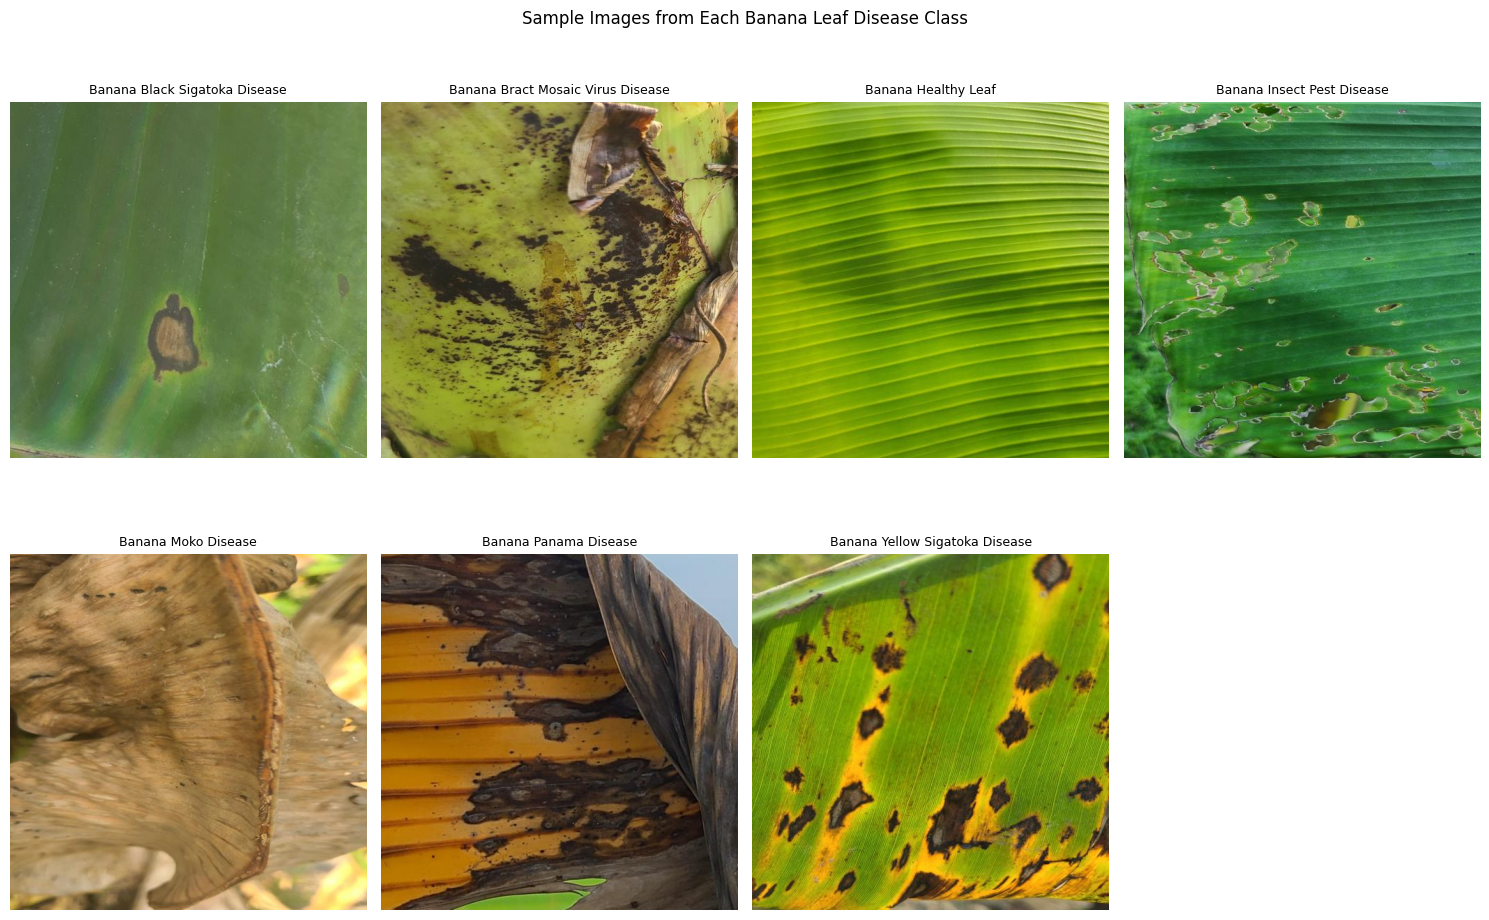

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/banana_dataset"

classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, images[0])
    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Images from Each Banana Leaf Disease Class")
plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image

dataset_path = "/content/banana_dataset"

total_images = 0
corrupted_images = []
image_sizes = {}

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            total_images += 1
            file_path = os.path.join(class_path, filename)

            try:
                with Image.open(file_path) as img:
                    size = img.size
                    image_sizes[size] = image_sizes.get(size, 0) + 1
            except Exception:
                corrupted_images.append(file_path)

print("Total images:", total_images)
print("Corrupted images:", len(corrupted_images))
print("Different image dimensions:", len(image_sizes))

print("\nMost common image sizes:")
for size, count in sorted(image_sizes.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(size, "->", count, "images")

Total images: 408
Corrupted images: 0
Different image dimensions: 1

Most common image sizes:
(512, 512) -> 408 images


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = "/content/banana_dataset"

data = []

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                data.append({
                    "filepath": os.path.join(class_path, filename),
                    "label": class_name
                })

df = pd.DataFrame(data)

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTesting distribution:")
print(test_df["label"].value_counts())

Training images: 285
Validation images: 61
Testing images: 62

Training distribution:
label
Banana Healthy Leaf                  60
Banana Insect Pest Disease           60
Banana Black Sigatoka Disease        47
Banana Moko Disease                  38
Banana Bract Mosaic Virus Disease    35
Banana Panama Disease                29
Banana Yellow Sigatoka Disease       16
Name: count, dtype: int64

Validation distribution:
label
Banana Healthy Leaf                  13
Banana Insect Pest Disease           13
Banana Black Sigatoka Disease        10
Banana Moko Disease                   8
Banana Bract Mosaic Virus Disease     7
Banana Panama Disease                 6
Banana Yellow Sigatoka Disease        4
Name: count, dtype: int64

Testing distribution:
label
Banana Healthy Leaf                  13
Banana Insect Pest Disease           13
Banana Black Sigatoka Disease        10
Banana Moko Disease                   9
Banana Bract Mosaic Virus Disease     8
Banana Panama Disease              

In [ ]:

!pip -q install scikit-image

In [ ]:
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def extract_hog_features(dataframe):
    features = []
    labels = []

    for _, row in dataframe.iterrows():
        image = imread(row["filepath"])

        # Resize all images to a common size
        image = resize(image, (128, 128))

        # Convert to grayscale
        if image.ndim == 3:
            image = np.mean(image, axis=2)

        # Extract HOG features
        hog_features = hog(
            image,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        features.append(hog_features)
        labels.append(row["label"])

    return np.array(features), np.array(labels)


print("Extracting HOG features...")

X_train_hog, y_train_hog = extract_hog_features(train_df)
X_val_hog, y_val_hog = extract_hog_features(val_df)
X_test_hog, y_test_hog = extract_hog_features(test_df)

print("Training feature shape:", X_train_hog.shape)
print("Validation feature shape:", X_val_hog.shape)
print("Testing feature shape:", X_test_hog.shape)

Extracting HOG features...
Training feature shape: (285, 8100)
Validation feature shape: (61, 8100)
Testing feature shape: (62, 8100)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("Training HOG + SVM model...")

start_time = time.time()

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced"
)

svm_model.fit(X_train_hog, y_train_hog)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")

Training HOG + SVM model...
Training completed in 0.63 seconds


HOG + SVM Accuracy: 0.4839
HOG + SVM Accuracy: 48.39%

Classification Report:
                                   precision    recall  f1-score   support

    Banana Black Sigatoka Disease       0.17      0.10      0.12        10
Banana Bract Mosaic Virus Disease       0.70      0.88      0.78         8
              Banana Healthy Leaf       0.75      0.92      0.83        13
       Banana Insect Pest Disease       0.27      0.46      0.34        13
              Banana Moko Disease       0.40      0.22      0.29         9
            Banana Panama Disease       1.00      0.17      0.29         6
   Banana Yellow Sigatoka Disease       0.50      0.33      0.40         3

                         accuracy                           0.48        62
                        macro avg       0.54      0.44      0.43        62
                     weighted avg       0.51      0.48      0.45        62



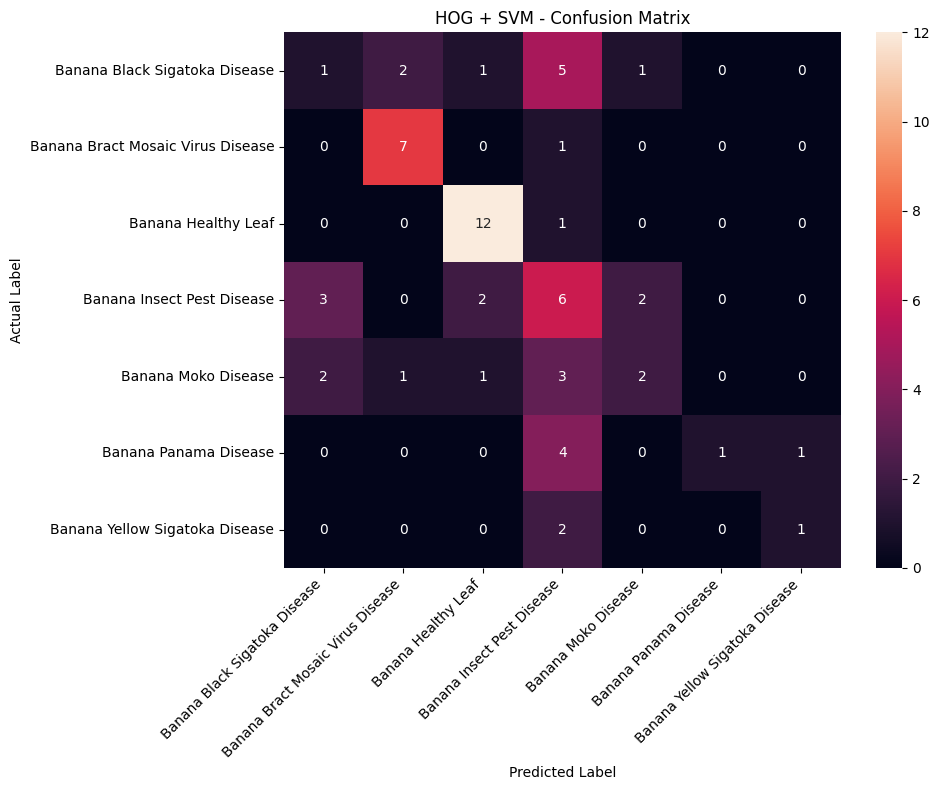

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the unseen test set
y_pred_svm = svm_model.predict(X_test_hog)

# Accuracy
svm_accuracy = accuracy_score(y_test_hog, y_pred_svm)

print(f"HOG + SVM Accuracy: {svm_accuracy:.4f}")
print(f"HOG + SVM Accuracy: {svm_accuracy * 100:.2f}%")

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test_hog, y_pred_svm))

# Confusion matrix
cm_svm = confusion_matrix(
    y_test_hog,
    y_pred_svm,
    labels=sorted(df["label"].unique())
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=sorted(df["label"].unique()),
    yticklabels=sorted(df["label"].unique())
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("HOG + SVM - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Image augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

# Validation and test: only preprocessing, no augmentation
val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

# Create generators from our existing dataframes
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train_generator.class_indices)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Testing images:", test_generator.samples)

Found 285 validated image filenames belonging to 7 classes.
Found 61 validated image filenames belonging to 7 classes.
Found 62 validated image filenames belonging to 7 classes.
Classes: {'Banana Black Sigatoka Disease': 0, 'Banana Bract Mosaic Virus Disease': 1, 'Banana Healthy Leaf': 2, 'Banana Insect Pest Disease': 3, 'Banana Moko Disease': 4, 'Banana Panama Disease': 5, 'Banana Yellow Sigatoka Disease': 6}
Training images: 285
Validation images: 61
Testing images: 62


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers
base_model.trainable = False

# Build our classifier
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(7, activation="softmax")
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time

# Calculate class weights from the training data
class_labels = sorted(train_df["label"].unique())

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_labels),
    y=train_df["label"]
)

class_weights = {
    train_generator.class_indices[label]: weight
    for label, weight in zip(class_labels, weights)
}

print("Class weights:")
for label, weight in zip(class_labels, weights):
    print(f"{label}: {weight:.2f}")

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7
)

# Train the model
start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

training_time_mobilenet = time.time()

Class weights:
Banana Black Sigatoka Disease: 0.87
Banana Bract Mosaic Virus Disease: 1.16
Banana Healthy Leaf: 0.68
Banana Insect Pest Disease: 0.68
Banana Moko Disease: 1.07
Banana Panama Disease: 1.40
Banana Yellow Sigatoka Disease: 2.54
Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.1930 - loss: 2.3350 - val_accuracy: 0.1148 - val_loss: 2.0957 - learning_rate: 1.0000e-04
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 912ms/step - accuracy: 0.2175 - loss: 2.2022 - val_accuracy: 0.2295 - val_loss: 1.8725 - learning_rate: 1.0000e-04
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 930ms/step - accuracy: 0.2912 - loss: 1.8546 - val_accuracy: 0.3279 - val_loss: 1.7115 - learning_rate: 1.0000e-04
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 941ms/step - accuracy: 0.3404 - loss: 1.7472 - val_accuracy: 0.3770 - val_loss: 1.5867 - learning_rate: 1.0000e-04
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 943ms/step - accuracy: 0.3965 - loss: 1.6425 - val_accuracy: 0.4426 - val_loss: 1.4660 - lea

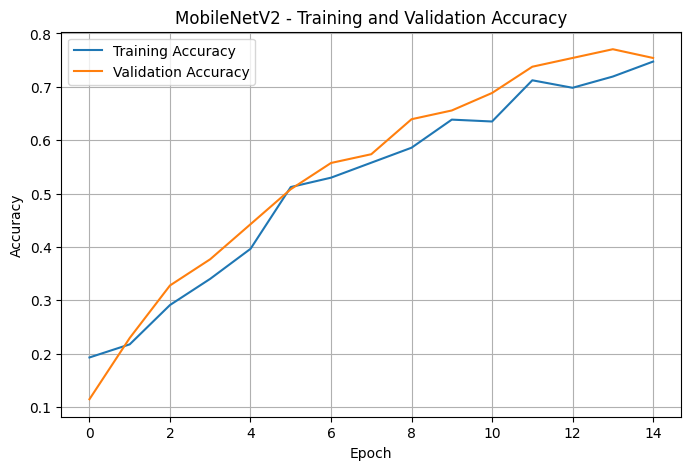

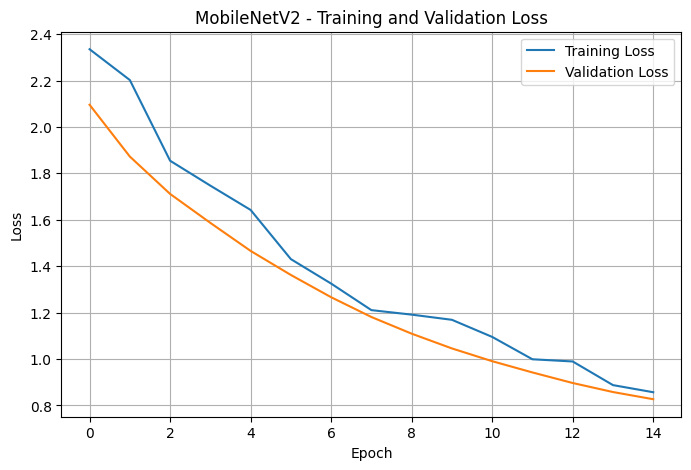

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate MobileNetV2 on the test set

test_loss, test_accuracy = model.evaluate(test_generator)

print("MobileNetV2 Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("MobileNetV2 Test Loss:", round(test_loss, 4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7581 - loss: 0.8396
MobileNetV2 Test Accuracy: 75.81 %
MobileNetV2 Test Loss: 0.8396


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step
MobileNetV2 Classification Report:

                                   precision    recall  f1-score   support

    Banana Black Sigatoka Disease       0.50      0.70      0.58        10
Banana Bract Mosaic Virus Disease       0.88      0.88      0.88         8
              Banana Healthy Leaf       1.00      1.00      1.00        13
       Banana Insect Pest Disease       0.91      0.77      0.83        13
              Banana Moko Disease       0.67      0.89      0.76         9
            Banana Panama Disease       1.00      0.17      0.29         6
   Banana Yellow Sigatoka Disease       0.33      0.33      0.33         3

                         accuracy                           0.76        62
                        macro avg       0.75      0.68      0.67        62
                     weighted avg       0.80      0.76      0.75        62



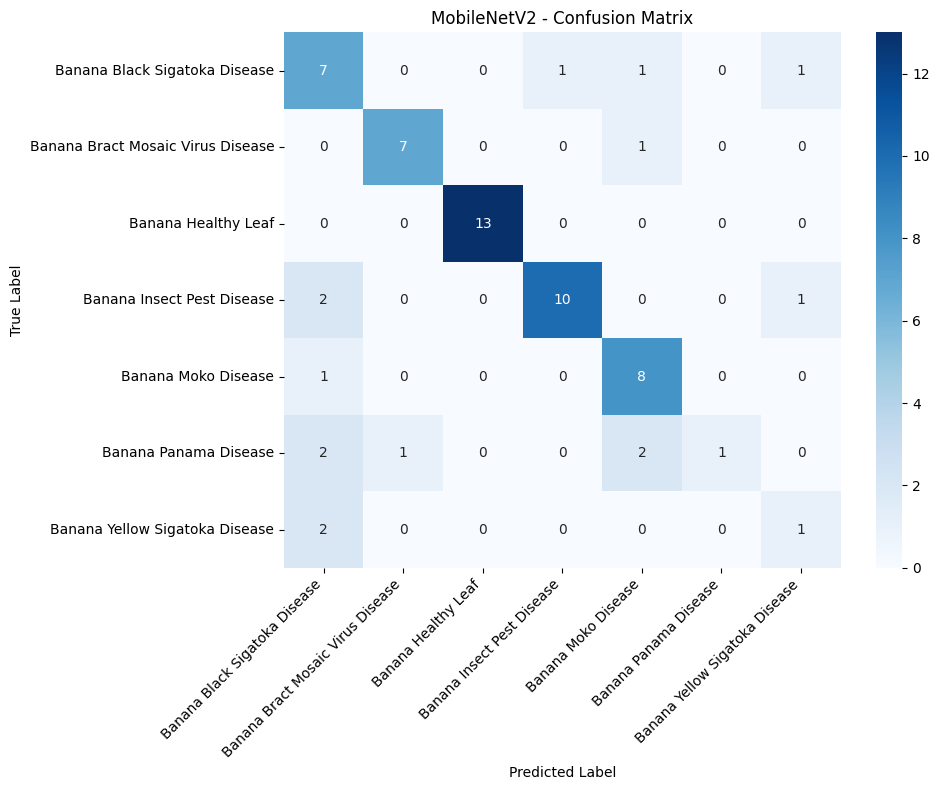

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reset test generator
test_generator.reset()

# Predictions
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
print("MobileNetV2 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained MobileNetV2 model

model.save("/content/banana_mobilenetv2.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("/content/banana_mobilenetv2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model Performance Comparison:


,Model,Test Accuracy
0,HOG + SVM,48.39
1,MobileNetV2,76.00


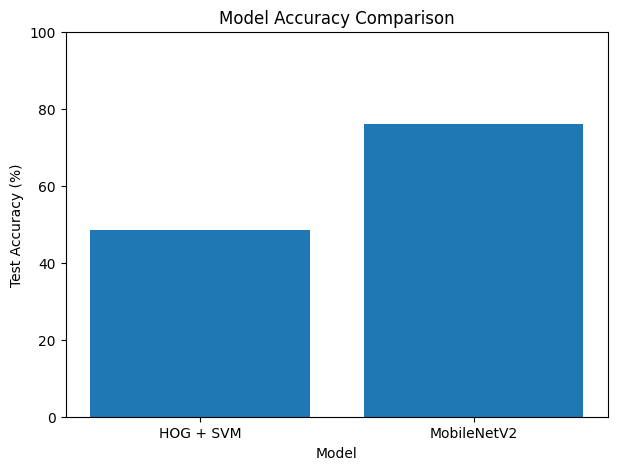

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Model performance comparison
comparison = pd.DataFrame({
    "Model": ["HOG + SVM", "MobileNetV2"],
    "Test Accuracy": [48.39, 76.00]
})

print("Model Performance Comparison:")
display(comparison)

# Accuracy comparison chart
plt.figure(figsize=(7, 5))
plt.bar(comparison["Model"], comparison["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.show()

## Final Conclusion

The Banana Leaf Disease Classification project was implemented using two approaches: HOG feature extraction with SVM and MobileNetV2 transfer learning.

The HOG + SVM model achieved a test accuracy of 48.39%, while the MobileNetV2 model achieved a significantly higher test accuracy of 76.00%.

Therefore, MobileNetV2 performed better than the traditional HOG + SVM approach for classifying banana leaf diseases. The results demonstrate that transfer learning with a pre-trained deep learning model can provide better classification performance for image-based disease detection.